In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

In [2]:
# Set global font sizes
font_size_global = 16
# Also remove top title
plt.rcParams['font.size'] = font_size_global
plt.rcParams['axes.titlesize'] = font_size_global
plt.rcParams['axes.labelsize'] = font_size_global
plt.rcParams['xtick.labelsize'] = font_size_global
plt.rcParams['ytick.labelsize'] = font_size_global
plt.rcParams['legend.fontsize'] = font_size_global

In [3]:
with open('data/results_all.pickle', 'rb') as f:
    results_all = pickle.load(f)

In [4]:
print(len(results_all))

5840


In [5]:
print(results_all[0].keys())

dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a', 'drag_graph', 'drag_bilstm', 'drag_token', 'drag_graph_a', 'drag_token_a', 'drag_adapter_a', 'non_serializable'])


In [6]:
print(results_all[100])

{'path': 'MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/gen_waltzes17.mid_adapter', 'guidance_arch': 'LoRA', 'contra': True, 'num_guidance_steps': 8, 'guidance_model': 'no', 'graph': 0.016576558059337082, 'bilstm': -0.027096745430254532, 'token': 0.025854844088647855, 'graph_a': -0.009046267937211416, 'token_a': 0.002804227976822383, 'adapter_a': 0.014061789302264927, 'drag_graph': None, 'drag_bilstm': None, 'drag_token': None, 'drag_graph_a': None, 'drag_token_a': None, 'drag_adapter_a': None, 'non_serializable': {'eval_object': {'graph': array([ 0.01799837, -0.05780333, -0.24357137,  0.01799837,  0.01373908,
        0.01799837, -0.08914326, -0.22432055, -0.24357137,  0.01799837,
        0.01799837, -0.05780333, -0.23836204,  0.01373908, -0.24357137,
        0.01799837, -0.24357137,  0.01799837, -0.11663313, -0.08914326]), 'bilstm': array([0.57010108, 0.62370443, 0.48089865, 0.57010108, 0.49165359,
       0.57010108, 0.48739663, 0.45808932, 0.48089865, 0.57010108,
       0.57010108, 0

In [7]:
ser_res = [{k: v for k, v in r.items() if k != 'non_serializable'} for r in results_all]

In [8]:
print(len(ser_res))
print(ser_res[101].keys())

5840
dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a', 'drag_graph', 'drag_bilstm', 'drag_token', 'drag_graph_a', 'drag_token_a', 'drag_adapter_a'])


In [9]:
print(ser_res[101]['guidance_model'])
print(ser_res[101]['drag_adapter_a'])

graph
0.11506450176239014


In [10]:
df = pd.DataFrame(ser_res)

In [11]:
df = df.dropna()

In [15]:
df.head(10)

,path,guidance_arch,contra,num_guidance_steps,guidance_model,graph,bilstm,token,graph_a,token_a,adapter_a,drag_graph,drag_bilstm,drag_token,drag_graph_a,drag_token_a,drag_adapter_a
1,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,graph,0.056809,-0.026249,0.033321,0.090070,0.061723,0.026537,0.150908,0.053955,0.095988,0.068198,0.199098,0.024787
2,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,bilstm,0.113620,0.045650,0.093784,0.146296,0.420714,0.237110,-0.659776,-0.011205,0.122297,-0.039500,0.321733,-0.002907
3,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,token,0.244826,0.185121,0.180392,0.394813,0.617117,0.316751,-0.659776,-0.011205,0.122297,0.072620,0.575183,0.075415
4,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,adapter,0.649437,0.287196,0.386706,0.616146,0.939391,0.544450,0.022559,0.110465,0.418508,0.328218,0.661587,0.287522
6,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,graph,0.213629,-0.061236,0.004538,0.146852,-0.045192,0.078491,0.232576,0.035869,0.157053,0.041793,0.180317,0.129810
7,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,bilstm,-0.016907,-0.131751,-0.038102,-0.113616,-0.135136,-0.021449,0.191452,-0.166748,0.046895,-0.273558,0.008239,0.044049
8,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,token,0.172635,0.204230,0.316353,0.265989,0.487613,0.344586,0.191452,-0.166748,0.046895,0.022419,0.565001,0.315139
9,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,adapter,0.716222,0.339898,0.372790,0.589190,0.589344,0.579756,0.334899,0.093352,0.172381,-0.017004,0.298142,0.174077
11,MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...,LoRA,True,8,graph,0.064888,-0.061393,-0.043053,0.068386,0.001402,0.034149,-0.437601,-0.190452,-0.178455,-0.016205,-0.131571,-0.089976
12,MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...,LoRA,True,8,bilstm,-0.118885,0.022191,0.093494,0.076940,0.112579,0.040178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


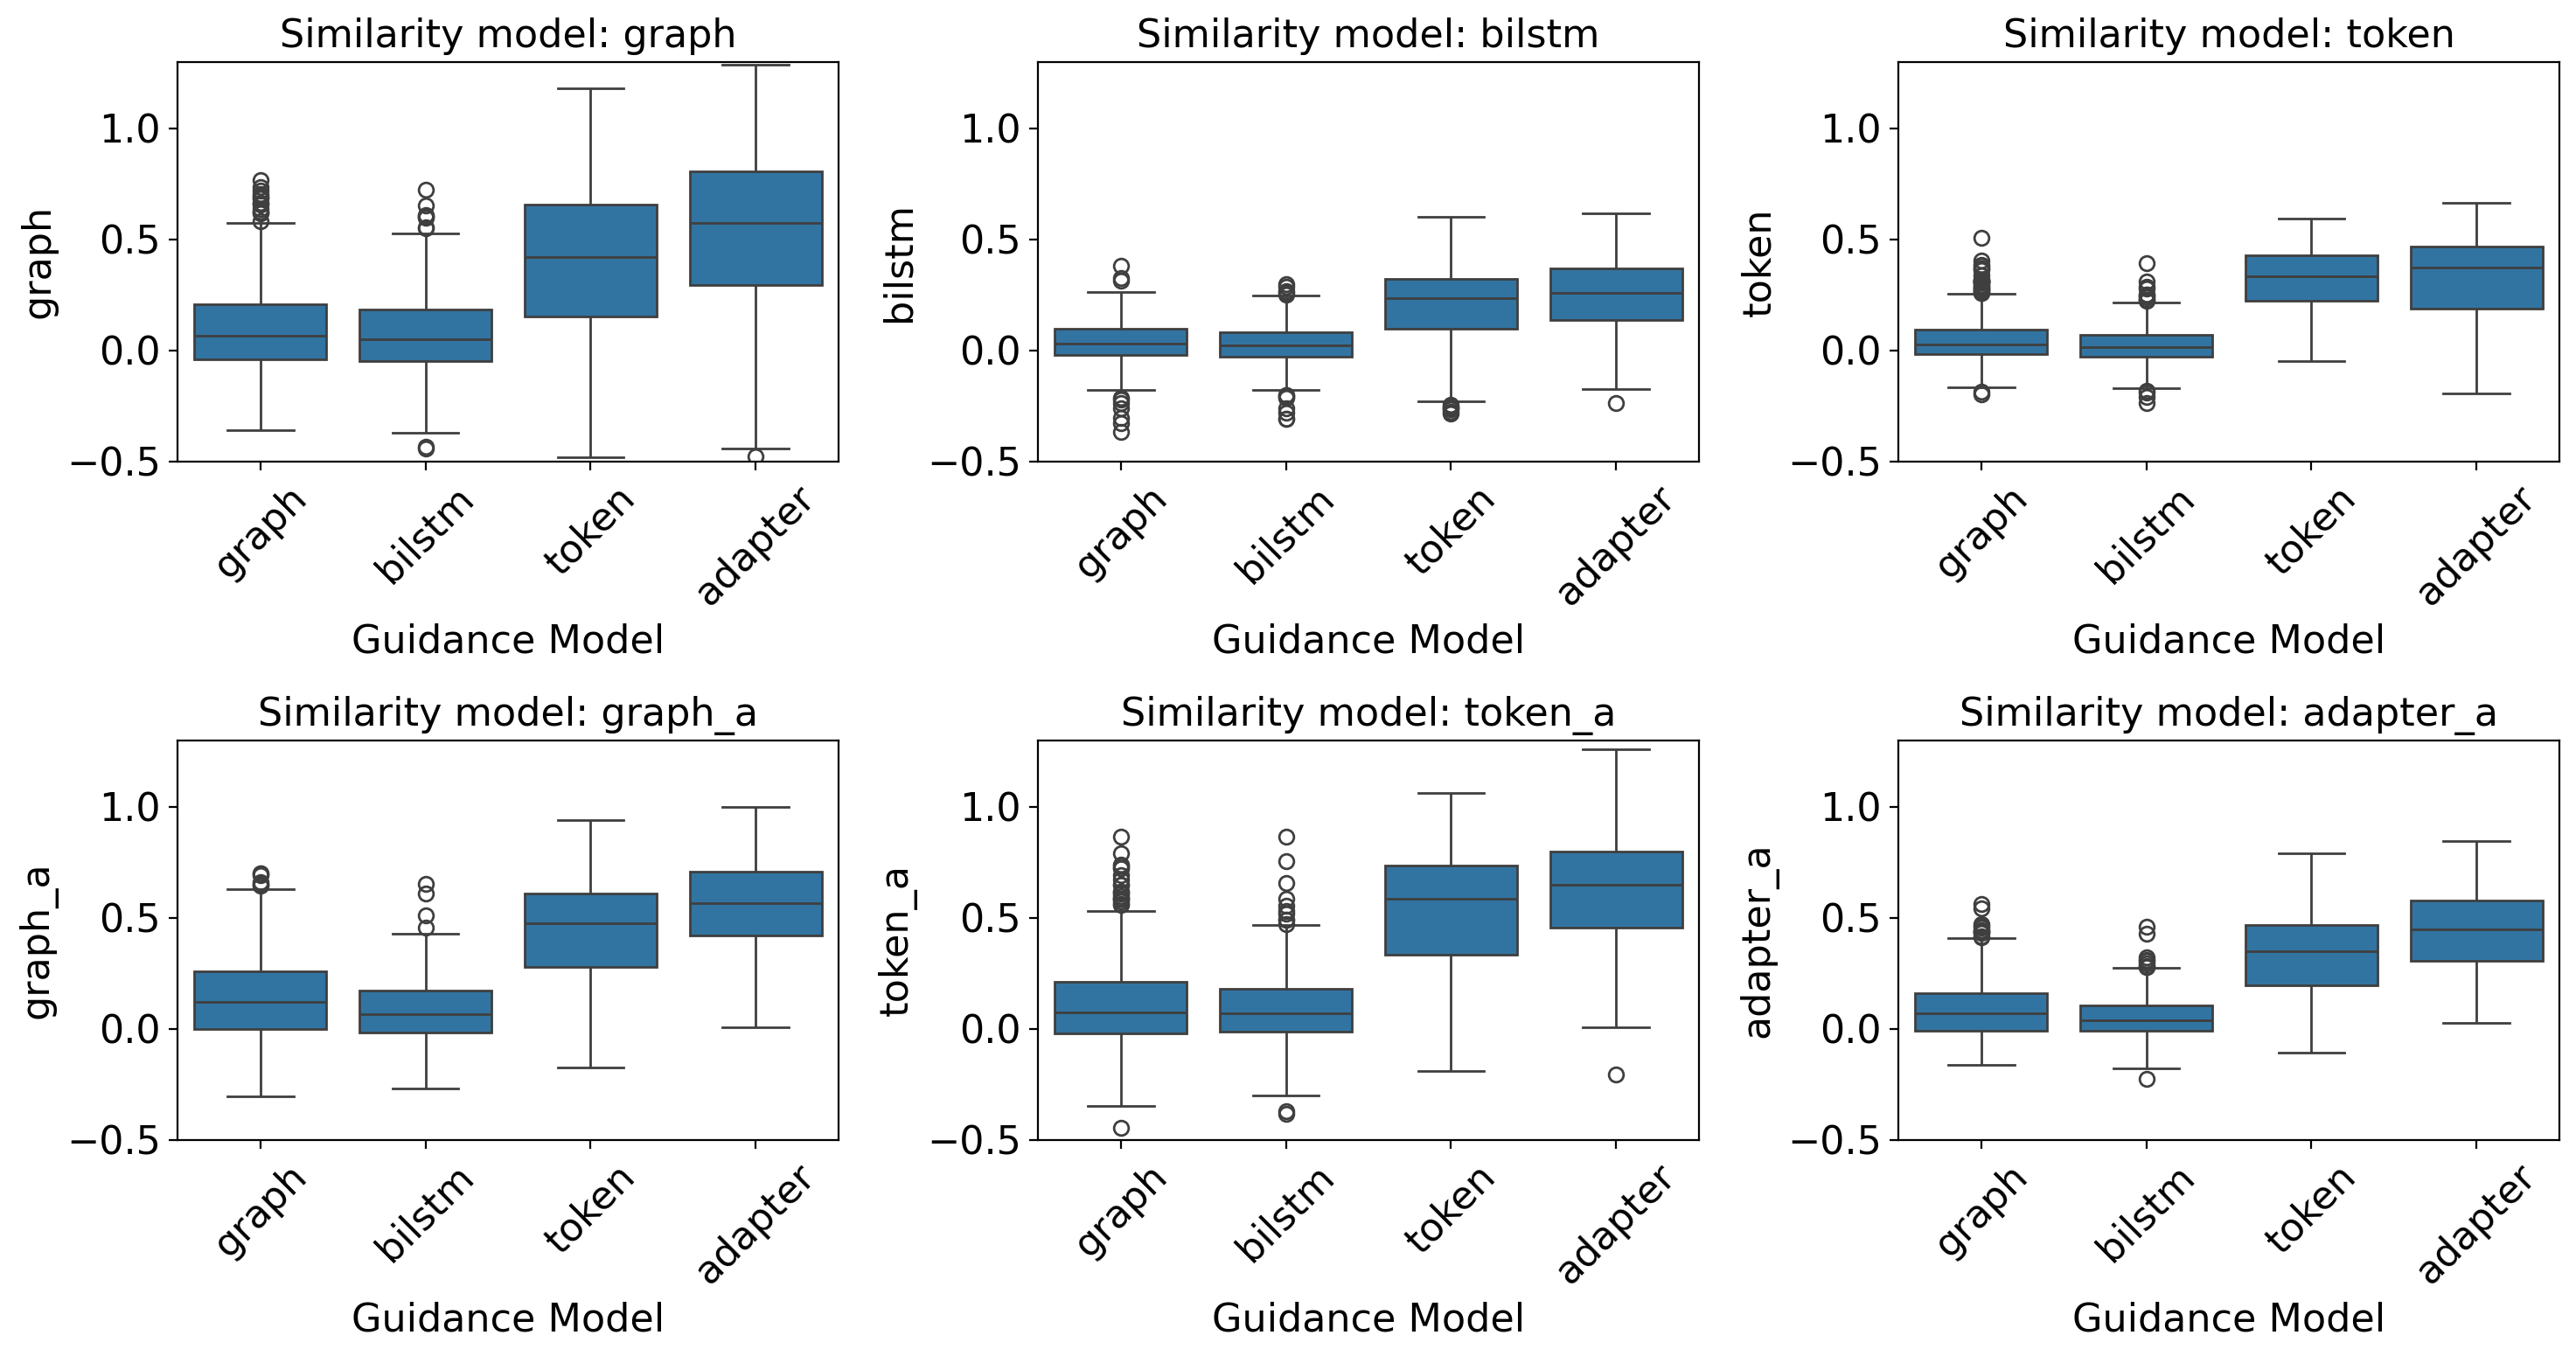

In [47]:
# Restrict the analysis to rows where contrastive training was enabled
# and select numeric metric columns automatically.
df_contra = df[df['contra'] == True].copy()
df_contra = df_contra[df_contra['guidance_model'] != 'no']

metrics = [
    col for col in df_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

ymin, ymax = -0.5, 1.3

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_ylim(ymin, ymax)
    axes[idx].set_title(f'Similarity model: {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig('figs/guidance_effectiveness.png', dpi=300)
plt.show()

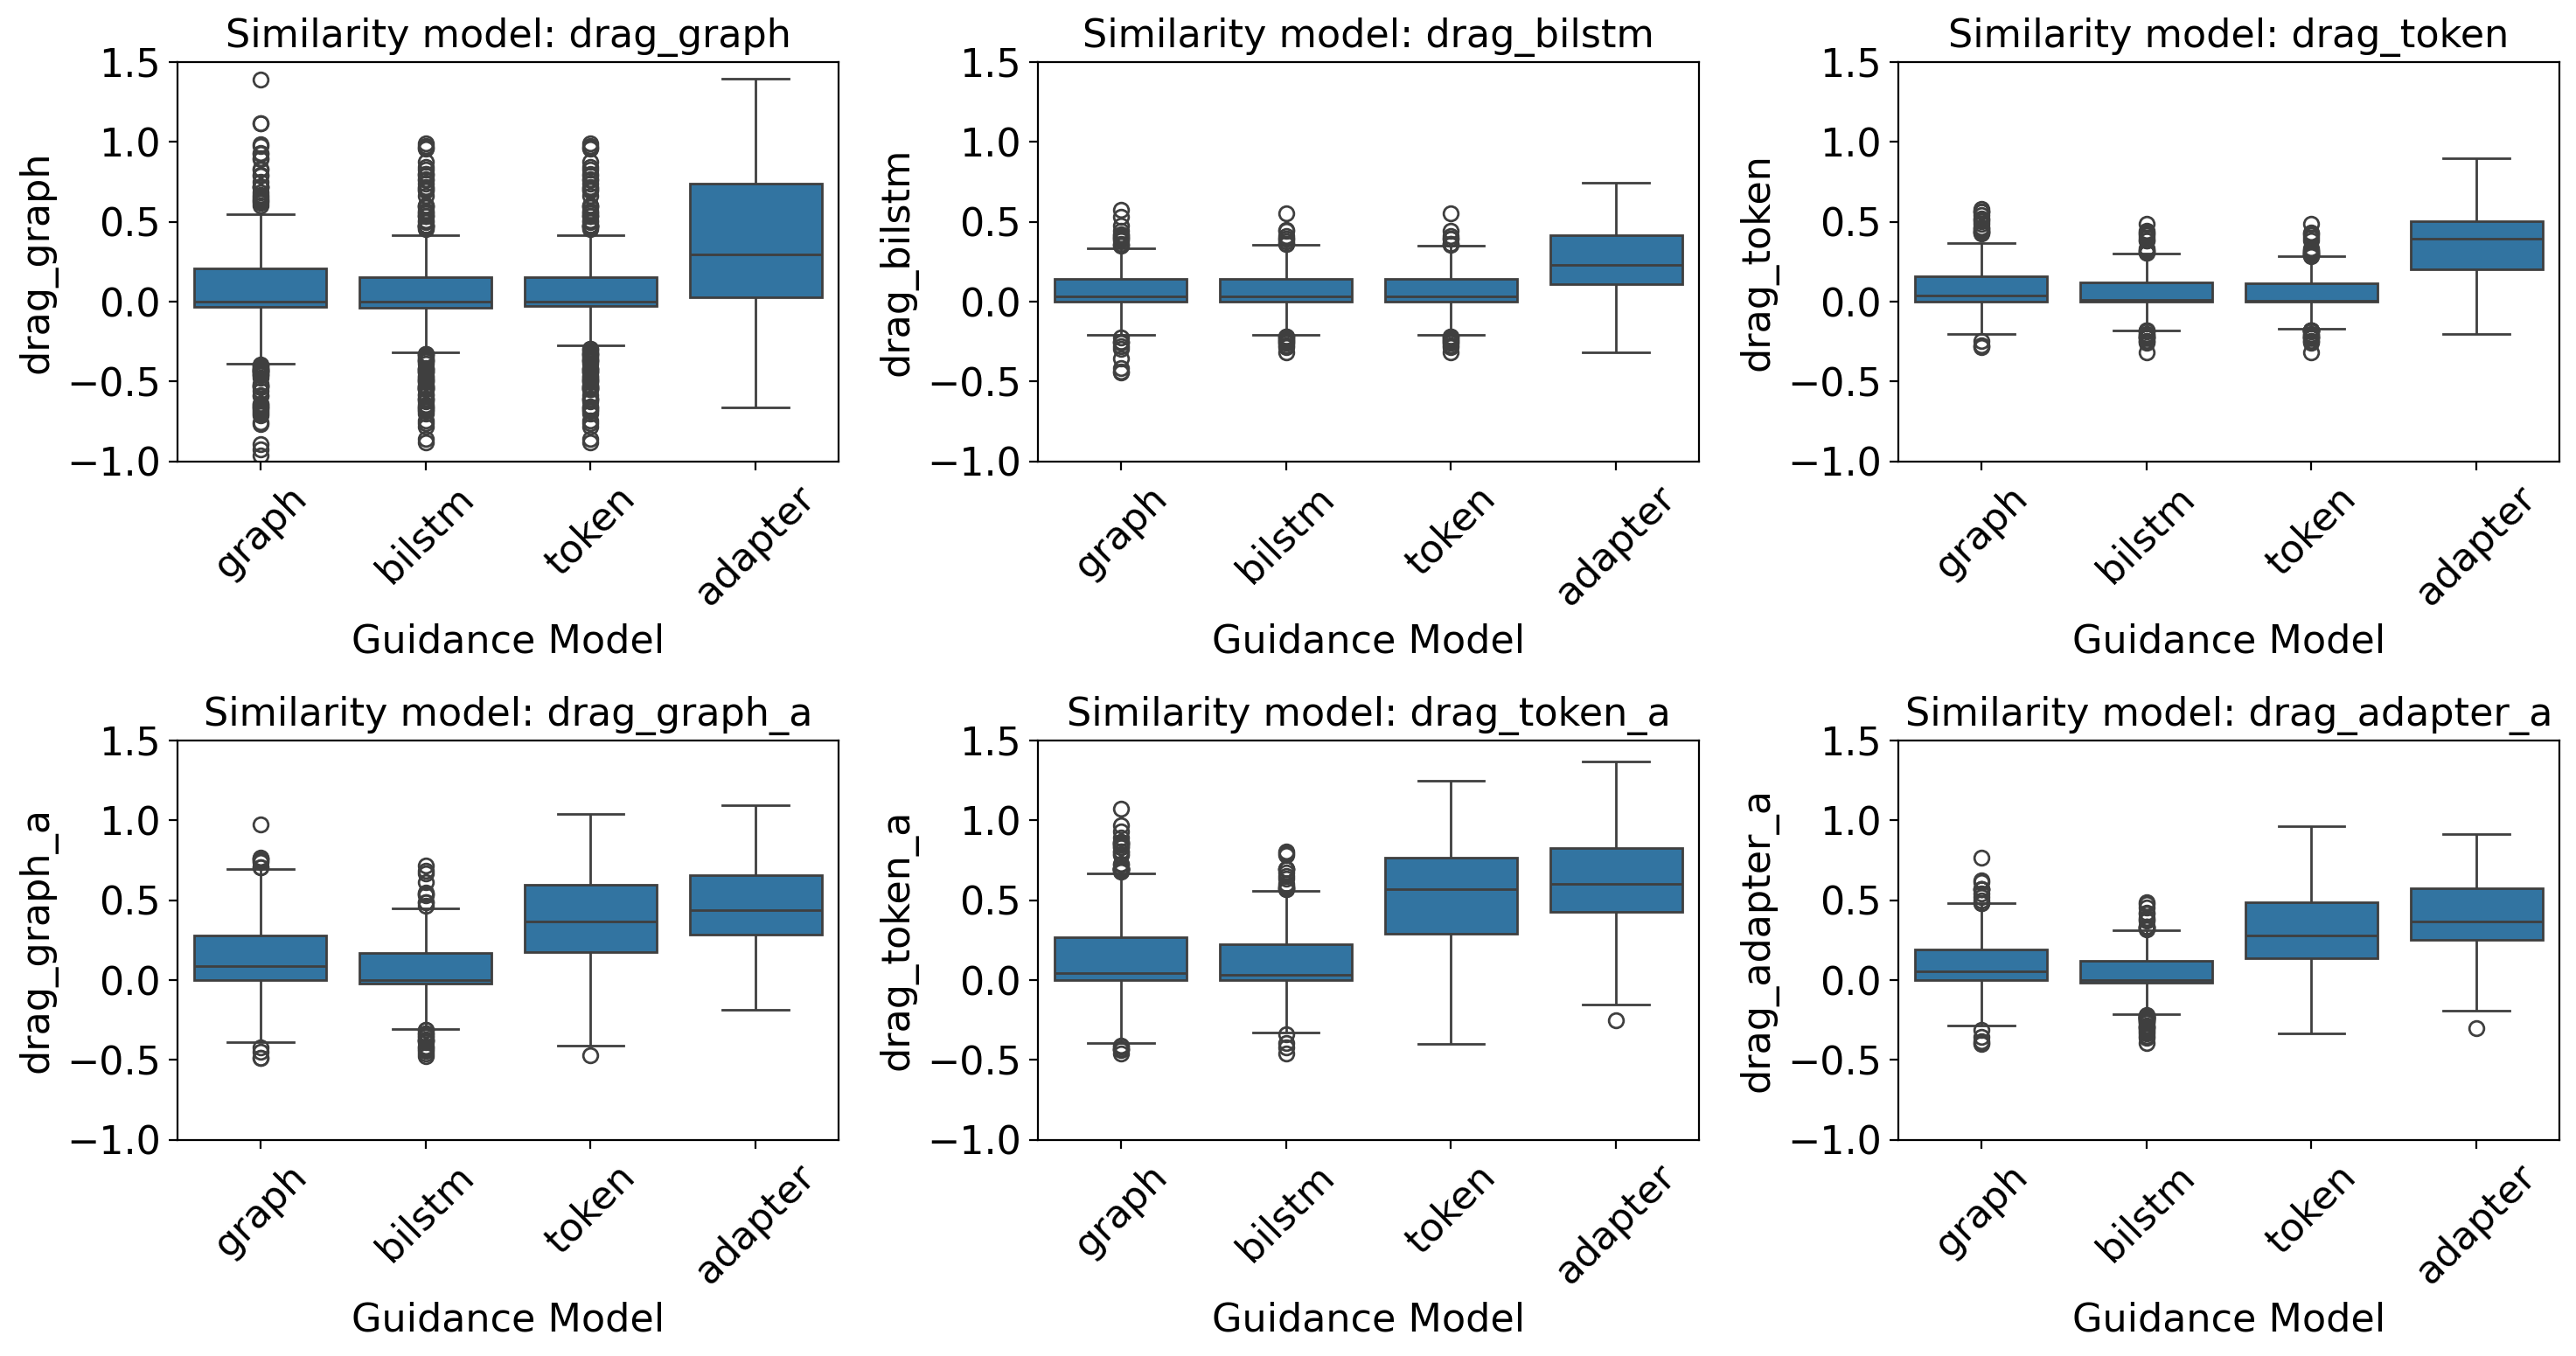

In [48]:
# drag
# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

ymin, ymax = -1.0, 1.5

for idx, metric in enumerate(metrics[len(axes):]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_ylim(ymin, ymax)
    axes[idx].set_title(f'Similarity model: {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig('figs/drag_effectiveness.png', dpi=300)
plt.show()

In [49]:
from scipy import stats

# Use the same filtered subset for the statistical comparison.
df_filtered = df[df['contra'] == True].copy()
df_filtered = df_filtered[df_filtered['guidance_model'] != 'no']

metrics = [
    col for col in df_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_filtered[df_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_filtered[df_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

            metric  u_statistic        p_value  significant
0            graph     117235.5   1.431469e-13         True
1           bilstm     134274.0   2.101657e-05         True
2            token     147311.0   6.408779e-02        False
3          graph_a     112671.0   1.803914e-16         True
4          token_a     129002.0   1.739262e-07         True
5        adapter_a     104911.0   4.274169e-22         True
6       drag_graph      90121.0   2.707236e-35         True
7      drag_bilstm      64390.5   6.446149e-66         True
8       drag_token      38625.5  2.541652e-106         True
9     drag_graph_a     128415.5   9.643062e-08         True
10    drag_token_a     133670.0   1.270546e-05         True
11  drag_adapter_a     118030.5   4.263910e-13         True


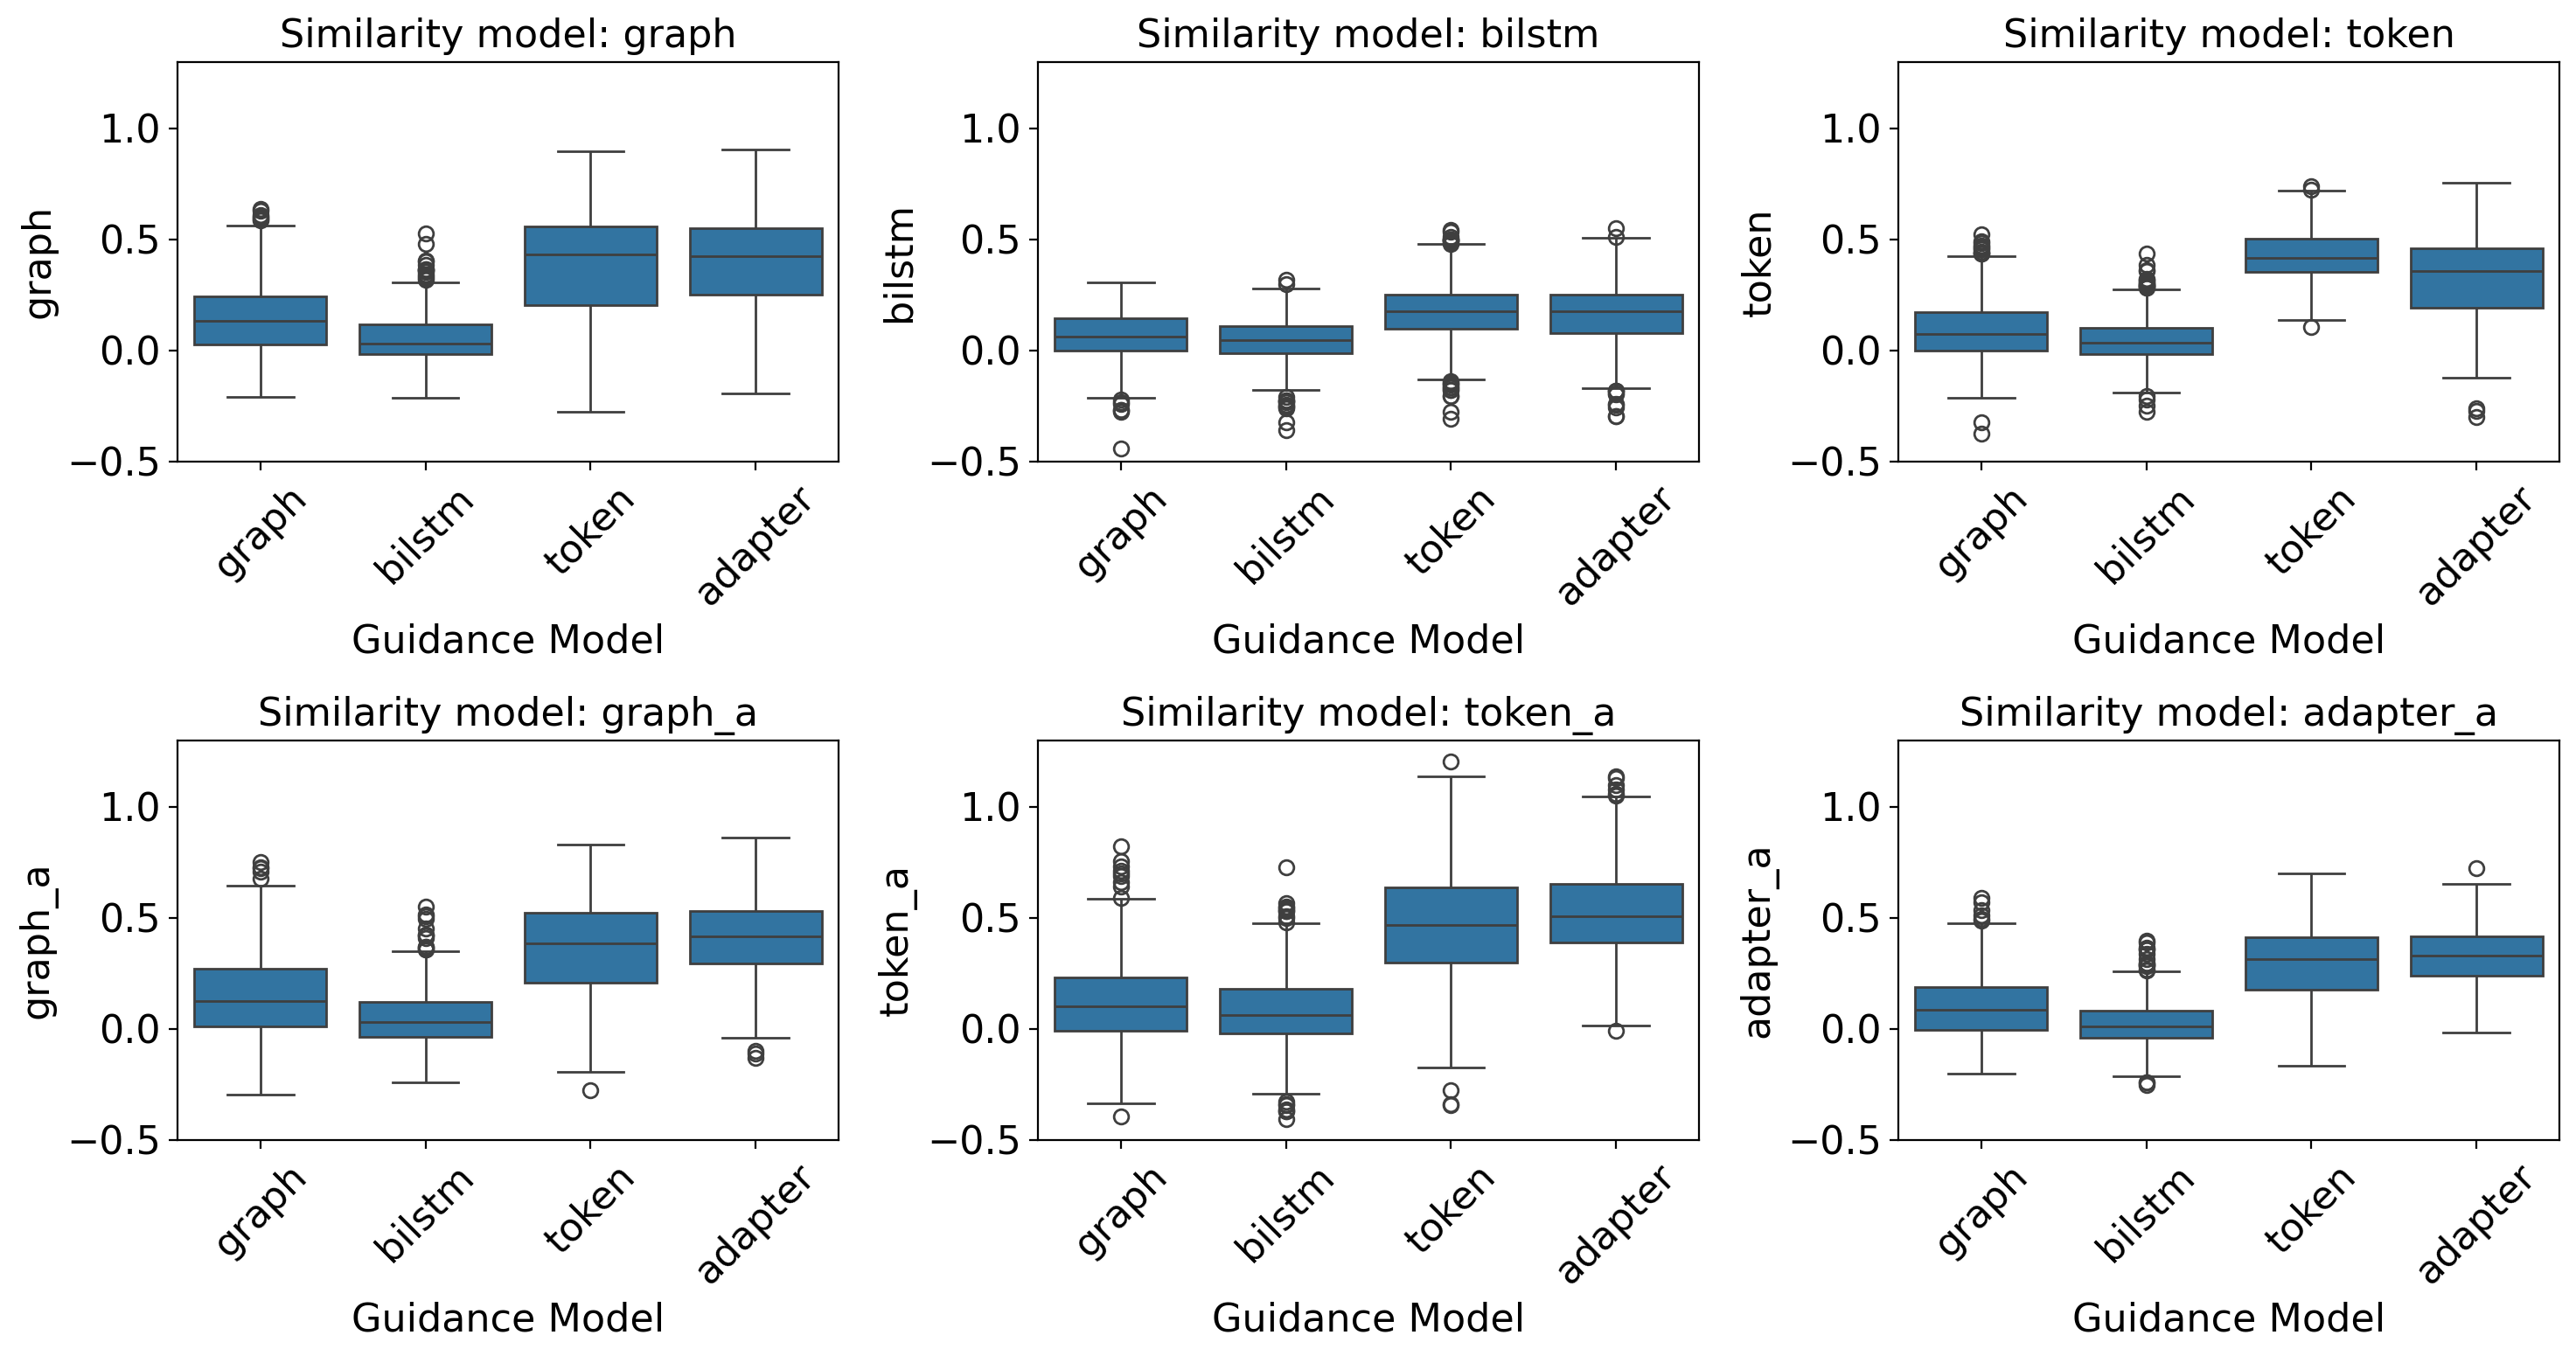

In [50]:
# Restrict the analysis to rows where contrastive training was NOT enabled
# and select numeric metric columns automatically.
df_no_contra = df[df['contra'] == False].copy()
df_no_contra = df_no_contra[df_no_contra['guidance_model'] != 'no']

metrics = [
    col for col in df_no_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_no_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

ymin, ymax = -0.5, 1.3

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_no_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_ylim(ymin, ymax)
    axes[idx].set_title(f'Similarity model: {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

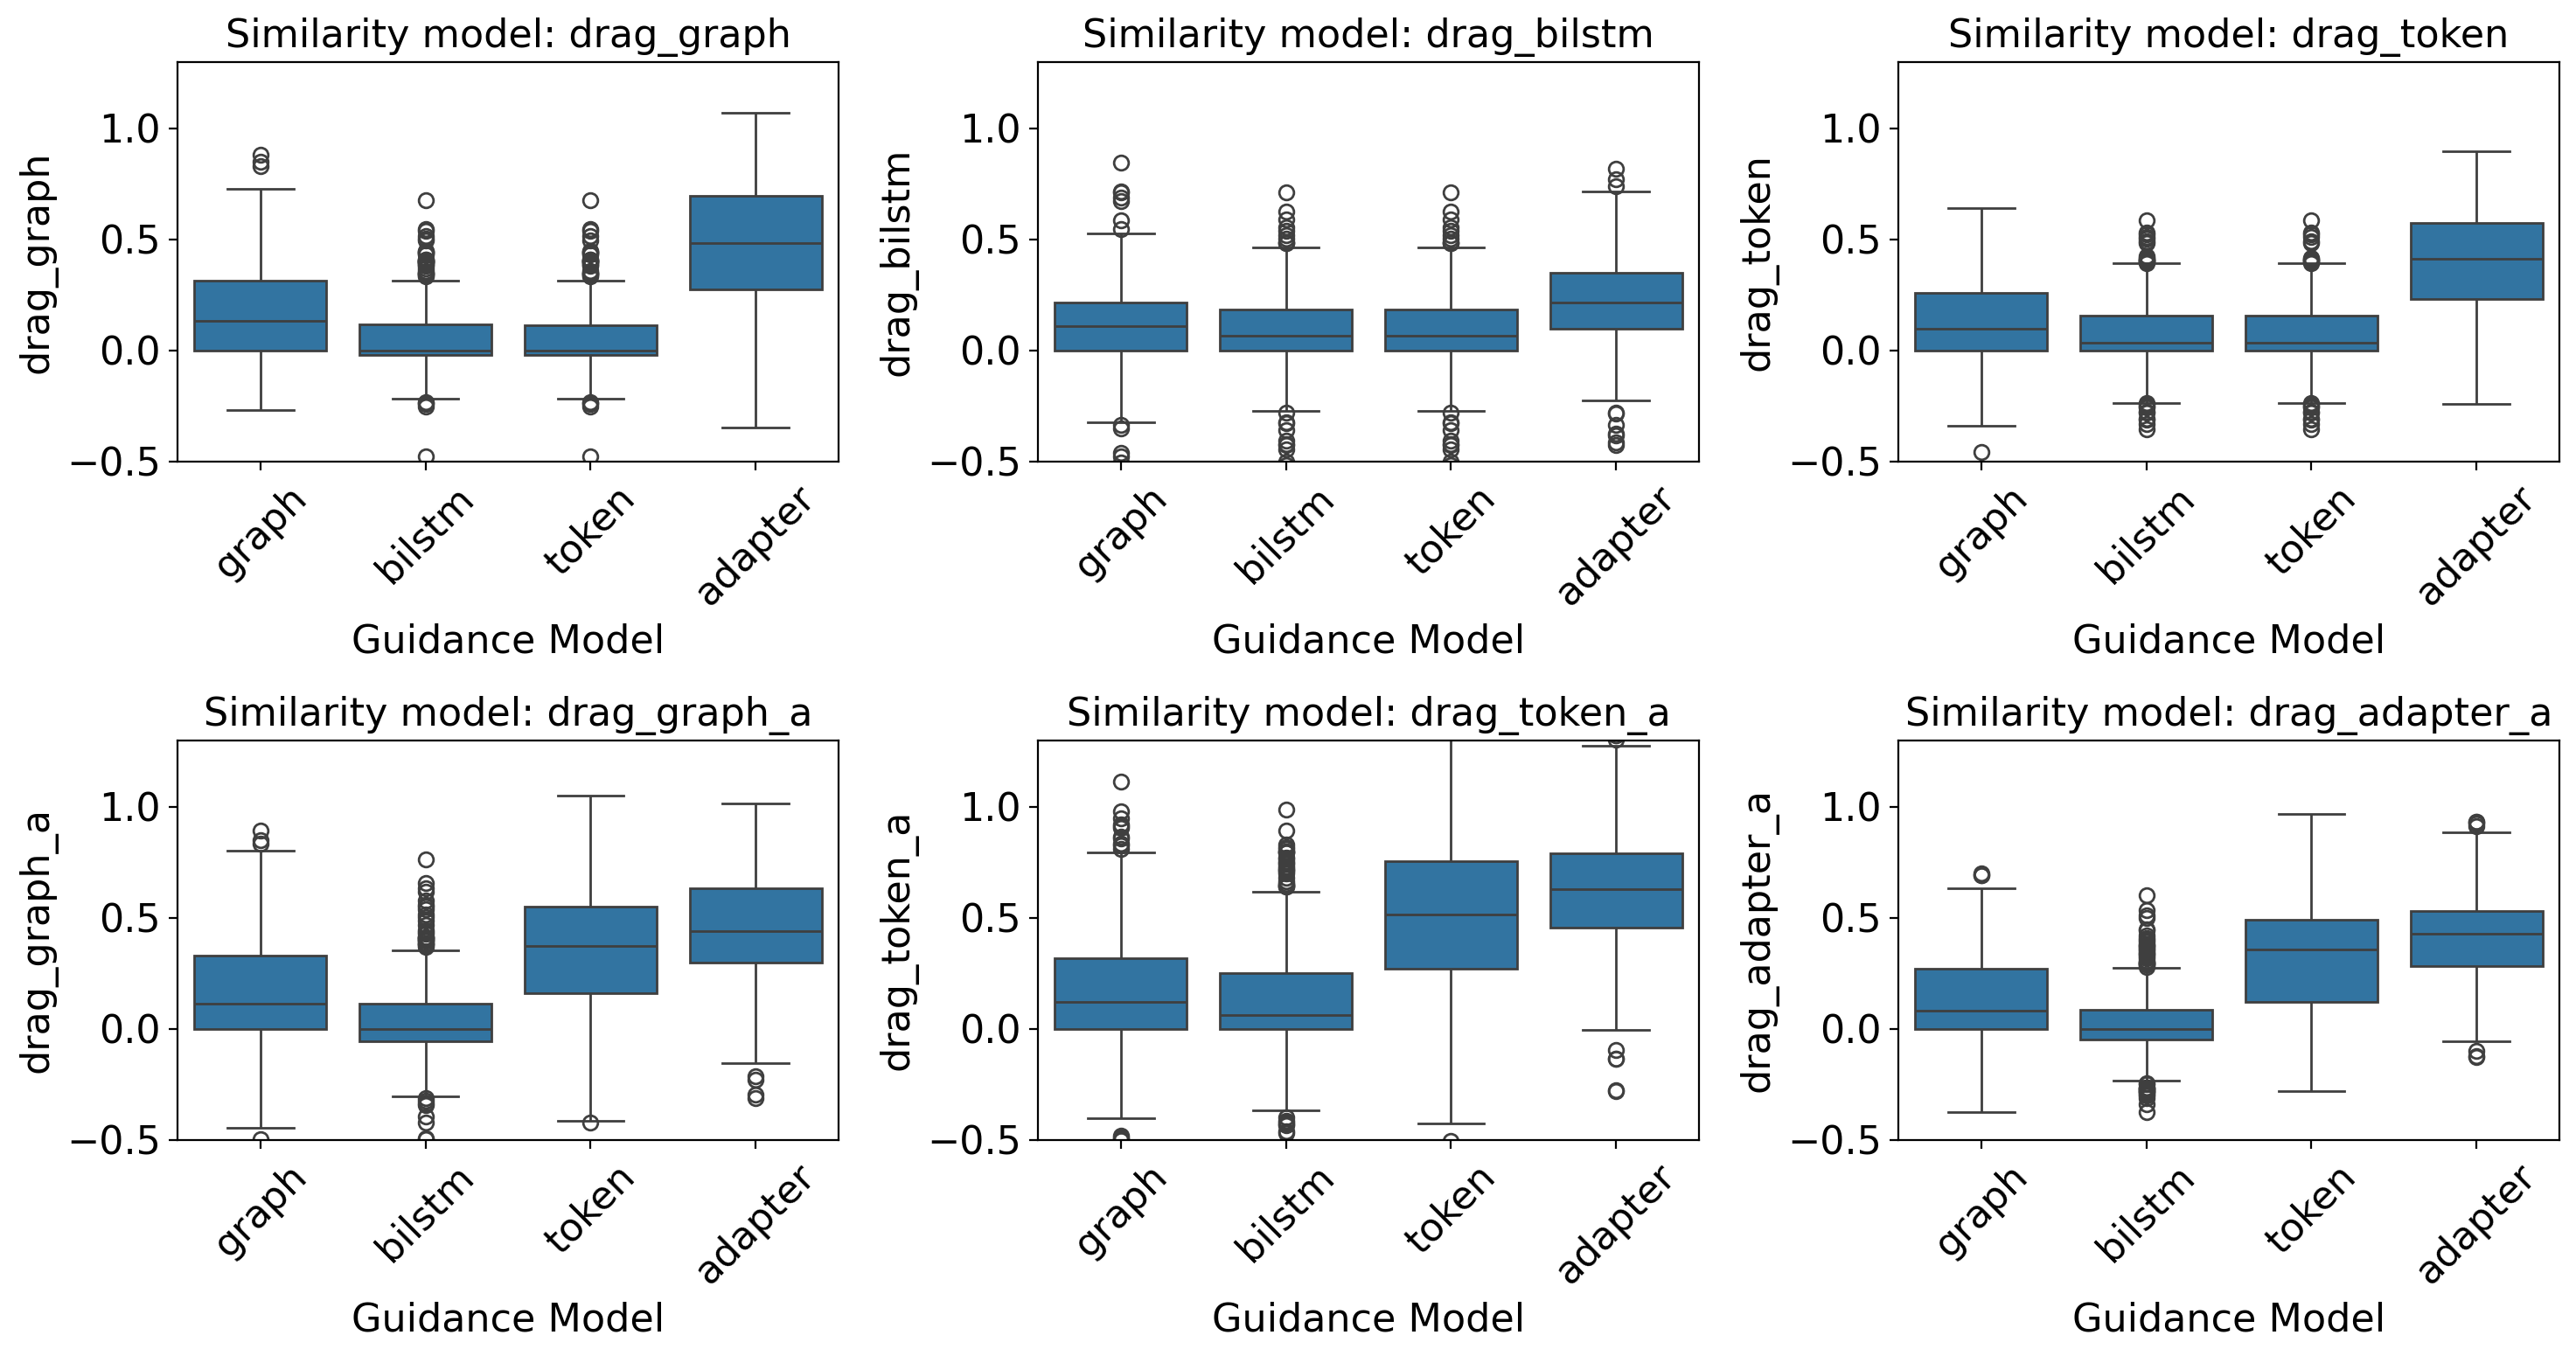

In [51]:
# drag
# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

ymin, ymax = -0.5, 1.3

for idx, metric in enumerate(metrics[len(axes):]):
    sns.boxplot(data=df_no_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_ylim(ymin, ymax)
    axes[idx].set_title(f'Similarity model: {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [52]:
# Use the same filtered subset for the statistical comparison.
df_no_filtered = df[df['contra'] == False].copy()
df_filtered = df_filtered[df_filtered['guidance_model'] != 'no']

metrics = [
    col for col in df_no_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_no_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_no_filtered[df_no_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_no_filtered[df_no_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

            metric  u_statistic        p_value  significant
0            graph     158354.5   5.248536e-01        False
1           bilstm     167625.0   3.000801e-01        False
2            token     209657.0   6.783899e-18         True
3          graph_a     143350.5   8.303257e-04         True
4          token_a     142360.0   4.296619e-04         True
5        adapter_a     143214.5   7.598632e-04         True
6       drag_graph      38204.0  2.264456e-110         True
7      drag_bilstm      92606.0   6.984171e-36         True
8       drag_token      41183.0  3.001986e-105         True
9     drag_graph_a     129124.5   3.447206e-09         True
10    drag_token_a     129756.0   6.838663e-09         True
11  drag_adapter_a     129466.0   5.000951e-09         True


/tmp/ipykernel_1082221/1010759758.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')


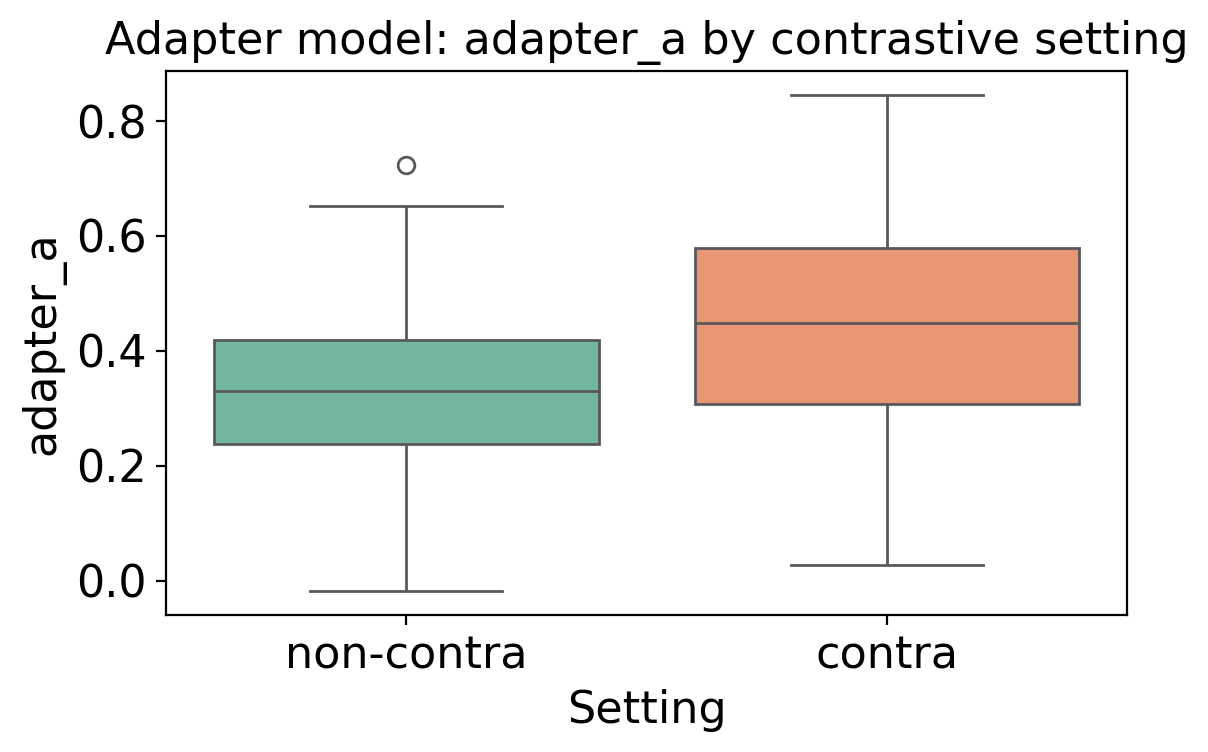

U statistic: 219940.000
p-value: 0.000000
Significant at 0.05: True


In [53]:
# Focus on the adapter model and pick the adapter metric column.
df_adapter = df[df['guidance_model'] == 'adapter'].copy()
metric_col = 'adapter_a' if 'adapter_a' in df_adapter.columns else next(
    (col for col in df_adapter.columns if col.startswith('adapter') and col.endswith('_a')),
    None,
)

if metric_col is None:
    raise ValueError(f"No adapter metric column found. Available columns: {df_adapter.columns.tolist()}")

# Make the contrastive labels easier to read.
df_adapter['contra_label'] = df_adapter['contra'].map({True: 'contra', False: 'non-contra'})

# Boxplot comparison.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')
plt.title(f'Adapter model: {metric_col} by contrastive setting')
plt.xlabel('Setting')
plt.ylabel(metric_col)
plt.tight_layout()
plt.show()

# Statistical significance test.
contra_true = df_adapter.loc[df_adapter['contra'] == True, metric_col].dropna()
contra_false = df_adapter.loc[df_adapter['contra'] == False, metric_col].dropna()

u_stat, p_value = stats.mannwhitneyu(contra_true, contra_false, alternative='two-sided')
print(f'U statistic: {u_stat:.3f}')
print(f'p-value: {p_value:.6f}')
print(f'Significant at 0.05: {p_value < 0.05}')

In [54]:
common = [
    'b_E:7_@2;A:9_@2',
    'b_G:7_@2;D:9_@2'
]
uncommon = [
    'b_C#:hdim7_@2;D#:min_@2',
    'b_C:dim_@2;E:maj_@2'
]
new_t_known_c = [
    'b_A:min_@2;C#:maj_@2',
    'b_G:maj_@2;A#:11_@2'
]
new_t_new_c = [
    'b_E:maj13_@2;G#:sus2_@2',
    'b_D#:minmaj7_@2;B:maj6_@2'
]

In [55]:
# seq_names = common
# seq_names = uncommon
# seq_names = new_t_known_c
# seq_names = new_t_new_c

In [56]:
# Restrict the analysis to rows where contrastive training was enabled
# and select numeric metric columns automatically.
# df_contra = df[df['contra'] == True].copy()
df_common = df_contra[df_contra['path'].str.contains(common[0], na=False) | df_contra['path'].str.contains(common[1], na=False)].copy()
df_uncommon = df_contra[df_contra['path'].str.contains(uncommon[0], na=False) | df_contra['path'].str.contains(uncommon[1], na=False)].copy()
df_ntkc = df_contra[df_contra['path'].str.contains(new_t_known_c[0], na=False) | df_contra['path'].str.contains(new_t_known_c[1], na=False)].copy()
df_ntnc = df_contra[df_contra['path'].str.contains(new_t_new_c[0], na=False) | df_contra['path'].str.contains(new_t_new_c[1], na=False)].copy()

print(df_contra.size)
print(df_common.size)
print(df_uncommon.size)
print(df_ntkc.size)
print(df_ntnc.size)
print(df_uncommon.head(10))

38760
9707
9690
9656
9707
                                                 path guidance_arch  contra  \
11  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
12  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
13  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
14  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
16  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
17  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
18  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
19  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
91  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
92  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   

    num_guidance_steps guidance_model     graph    bilstm     token   graph_a  \
11                   8 

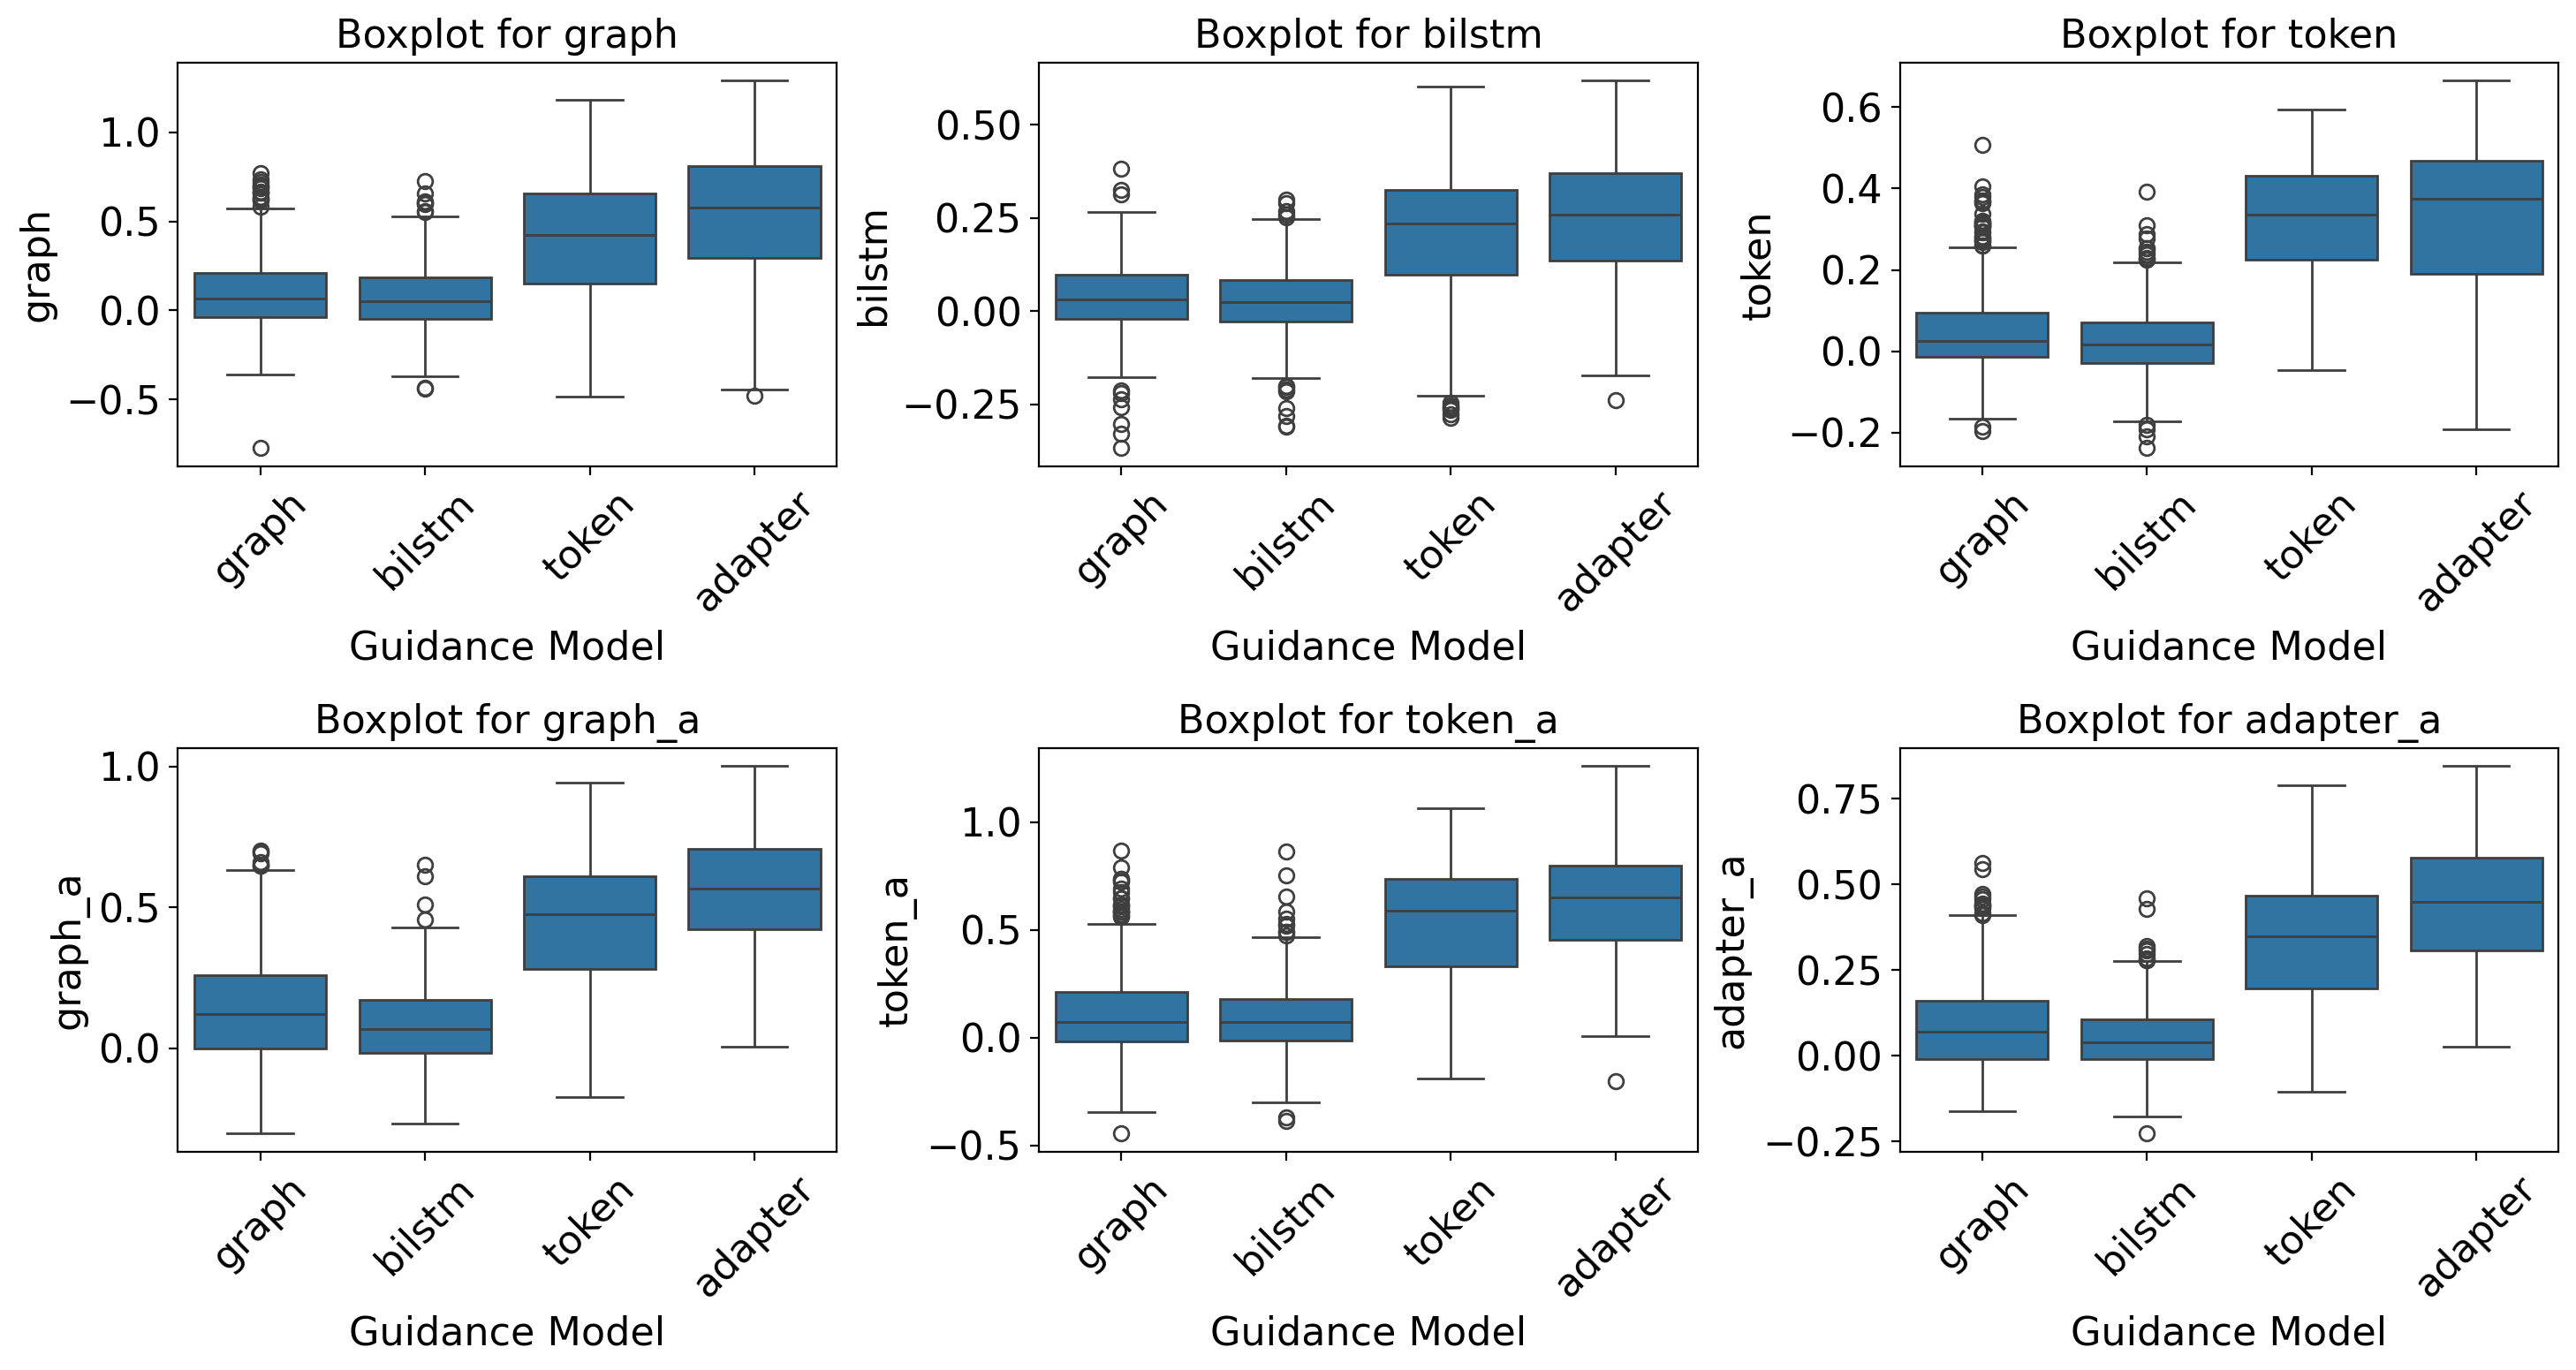

In [57]:
# df_current = df_common
# df_current = df_uncommon
# df_current = df_ntkc
df_current = df_ntnc

metrics = [
    col for col in df_current.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_current[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [58]:
import numpy as np
from scipy import stats

# df_common = df_contra[df_contra['path'].str.contains(seq_name, na=False)].copy()

metrics = [
    col for col in df_current.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_current[col])
]

results = []
for metric in metrics:
    token_data = df_current.loc[df_current['guidance_model'] == 'token', metric].dropna()
    adapter_data = df_current.loc[df_current['guidance_model'] == 'adapter', metric].dropna()

    if len(token_data) == 0 or len(adapter_data) == 0:
        results.append({
            'metric': metric,
            'u_statistic': np.nan,
            'p_value': np.nan,
            'significant': False,
            'note': 'missing token or adapter rows'
        })
        continue

    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data, alternative='two-sided')
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

            metric  u_statistic       p_value  significant
0            graph       5206.0  1.850727e-12         True
1           bilstm       4734.0  1.098075e-14         True
2            token      16917.0  5.283648e-23         True
3          graph_a       3134.0  1.022790e-23         True
4          token_a       6712.0  1.121292e-06         True
5        adapter_a       2963.0  8.105569e-25         True
6       drag_graph       9295.0  2.553975e-01        False
7      drag_bilstm       8649.0  3.823649e-02        False
8       drag_token       8115.0  4.443710e-03        False
9     drag_graph_a       4266.0  4.328861e-17         True
10    drag_token_a       5313.0  5.552908e-12         True
11  drag_adapter_a       4765.0  1.559468e-14         True


In [59]:
token_data

33     -0.038208
38     -0.077560
113    -0.233688
118    -0.139905
193    -0.163874
          ...   
5638    0.233574
5713    0.255555
5718    0.112955
5793    0.144536
5798   -0.024673
Name: drag_adapter_a, Length: 142, dtype: float64

In [60]:
def boxplot_summary_table(df, group_col='guidance_model', exclude=None):
    if exclude is None:
        exclude = {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}

    metrics = [
        col for col in df.columns
        if col not in exclude and pd.api.types.is_numeric_dtype(df[col])
    ]

    agg_spec = {}
    for metric in metrics:
        agg_spec[f"{metric}_median"] = (metric, "median")
        # agg_spec[f"{metric}_q1"] = (metric, lambda s: s.quantile(0.25))
        # agg_spec[f"{metric}_q3"] = (metric, lambda s: s.quantile(0.75))
        # agg_spec[f"{metric}_iqr"] = (metric, lambda s: s.quantile(0.75) - s.quantile(0.25))
        # agg_spec[f"{metric}_n"] = (metric, "count")

    summary = df.groupby(group_col).agg(**agg_spec).reset_index()
    return summary

In [61]:
# # for long table use this:
# def boxplot_summary_long(df, group_col='guidance_model', exclude=None):
#     if exclude is None:
#         exclude = {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}

#     metrics = [
#         col for col in df.columns
#         if col not in exclude and pd.api.types.is_numeric_dtype(df[col])
#     ]

#     rows = []
#     for model, g in df.groupby(group_col):
#         for metric in metrics:
#             rows.append({
#                 group_col: model,
#                 'metric': metric,
#                 'median': g[metric].median(),
#                 'q1': g[metric].quantile(0.25),
#                 'q3': g[metric].quantile(0.75),
#                 'iqr': g[metric].quantile(0.75) - g[metric].quantile(0.25),
#                 'n': g[metric].count()
#             })

#     return pd.DataFrame(rows)

In [62]:
summary_contra = boxplot_summary_table(df_contra)
print(summary_contra.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median  drag_graph_median  drag_bilstm_median  drag_token_median  drag_graph_a_median  drag_token_a_median  drag_adapter_a_median
       adapter         0.575          0.259         0.374           0.565           0.651             0.449              0.295               0.232              0.396                0.440                0.600                  0.368
        bilstm         0.049          0.025         0.017           0.068           0.071             0.040              0.000               0.035              0.011                0.000                0.031                  0.000
         graph         0.067          0.031         0.026           0.120           0.074             0.070              0.000               0.033              0.040                0.085                0.046                  0.054
         token         0.422          0.234         0.335           0.475   

In [63]:
summary_common = boxplot_summary_table(df_common)
print(summary_common.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median  drag_graph_median  drag_bilstm_median  drag_token_median  drag_graph_a_median  drag_token_a_median  drag_adapter_a_median
       adapter         0.732          0.330         0.410           0.633           0.740             0.564              0.335               0.302              0.443                0.371                0.690                  0.398
        bilstm         0.076          0.026         0.047           0.068           0.102             0.061              0.026               0.031              0.059                0.000                0.077                  0.000
         graph         0.086          0.047         0.063           0.147           0.098             0.080              0.000               0.056              0.132                0.125                0.115                  0.080
         token         0.494          0.264         0.357           0.461   

In [64]:
summary_uncommon = boxplot_summary_table(df_uncommon)
print(summary_uncommon.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median  drag_graph_median  drag_bilstm_median  drag_token_median  drag_graph_a_median  drag_token_a_median  drag_adapter_a_median
       adapter         0.683          0.286         0.400           0.693           0.743             0.538              0.367               0.218              0.403                0.600                0.786                  0.497
        bilstm         0.046          0.023         0.007           0.073           0.044             0.031              0.000               0.002              0.000                0.000                0.000                  0.000
         graph         0.071          0.021         0.027           0.120           0.074             0.048              0.000               0.000              0.000                0.045                0.000                  0.056
         token         0.562          0.246         0.337           0.597   

In [65]:
summary_ntkc = boxplot_summary_table(df_ntkc)
print(summary_ntkc.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median  drag_graph_median  drag_bilstm_median  drag_token_median  drag_graph_a_median  drag_token_a_median  drag_adapter_a_median
       adapter         0.650          0.320         0.452           0.557           0.693             0.442              0.424               0.398              0.503                0.458                0.668                  0.401
        bilstm         0.038          0.027         0.007           0.059           0.078             0.037              0.003               0.058              0.017                0.017                0.023                  0.007
         graph         0.038          0.048         0.017           0.092           0.060             0.053              0.000               0.071              0.030                0.100                0.028                  0.054
         token         0.573          0.343         0.462           0.558   

In [66]:
summary_ntnc = boxplot_summary_table(df_ntnc)
print(summary_ntnc.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median  drag_graph_median  drag_bilstm_median  drag_token_median  drag_graph_a_median  drag_token_a_median  drag_adapter_a_median
       adapter         0.178          0.061         0.025           0.339           0.287             0.245              0.088               0.085              0.059                0.332                0.345                  0.247
        bilstm         0.034          0.023         0.003           0.068           0.076             0.048              0.000               0.027              0.000                0.000                0.074                  0.000
         graph         0.076          0.013         0.011           0.130           0.071             0.094              0.001               0.017              0.027                0.067                0.050                  0.036
         token        -0.005         -0.038         0.158           0.126   

In [67]:
dfs = [
    summary_contra,
    summary_uncommon,
    summary_ntkc,
    summary_ntnc
]

common_cols = [c for c in dfs[0].columns if all(c in df.columns for df in dfs[1:])]
summary_all = pd.concat(
    [df[common_cols] for df in dfs],
    axis=0,
    ignore_index=True
)

In [68]:
print(summary_all)

   guidance_model  graph_median  bilstm_median  token_median  graph_a_median  \
0         adapter      0.575222       0.258633      0.374408        0.565365   
1          bilstm      0.049489       0.024624      0.016560        0.067537   
2           graph      0.067013       0.030814      0.026015        0.119899   
3           token      0.421636       0.234151      0.335307        0.474893   
4         adapter      0.683007       0.285697      0.399741        0.692831   
5          bilstm      0.045709       0.023087      0.007305        0.072627   
6           graph      0.071418       0.020878      0.026870        0.119833   
7           token      0.561798       0.245918      0.336941        0.596583   
8         adapter      0.650031       0.319676      0.451781        0.556950   
9          bilstm      0.037840       0.026786      0.007284        0.058701   
10          graph      0.037810       0.048160      0.016720        0.091886   
11          token      0.573093       0.

In [72]:
summary_local = summary_all[['guidance_model', 'graph_median', 'bilstm_median', 'token_median', 'graph_a_median', 'token_a_median', 'adapter_a_median']]
summary_drag = summary_all[['guidance_model', 'drag_graph_median', 'drag_bilstm_median', 'drag_token_median', 'drag_graph_a_median', 'drag_token_a_median', 'drag_adapter_a_median']]

In [73]:
latex_tables_base_path = 'results/latex_tables/'
os.makedirs(latex_tables_base_path, exist_ok=True)

summary_local.to_latex(
    latex_tables_base_path + 'guided_gen_local_analysis.tex',
    index=False,
    float_format="%.3f"
)
summary_drag.to_latex(
    latex_tables_base_path + 'guided_gen_drag_analysis.tex',
    index=False,
    float_format="%.3f"
)